In [1]:
import numpy as np
import pandas as pd
import h5py
import os, sys
import torch
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from typing import Dict, List
sys.path.append('../')
from config import JUNCTIONS, get_file_paths, get_file_paths_list, reverse_complement
from get_logits import *

In [2]:
tokenizer = AutoTokenizer.from_pretrained('kuleshov-group/PlantCaduceus_l32')

In [3]:
labels_dict = {}
for idx, junction in enumerate(JUNCTIONS):
    label = pd.read_csv(get_file_paths('labels', '../../../results/pseudo_gene/splice_junctions/')[junction], sep='\t')
    for model in ['pcv1', 'pcv2_1', 'pcv2_2', 'pcv2_3', 'evo2_fwd', 'evo2_rc']:
        scores = get_averaged_probs(model, idx, tokenizer, base_dir='../../../results/pseudo_gene/outputs/', chunk_size=None, JUNCTIONS=JUNCTIONS)
        label[f'{model}_scores'] = scores

    label['evo2_avg_scores'] = (label['evo2_fwd_scores'] + label['evo2_rc_scores']) / 2
    labels_dict[junction] = label

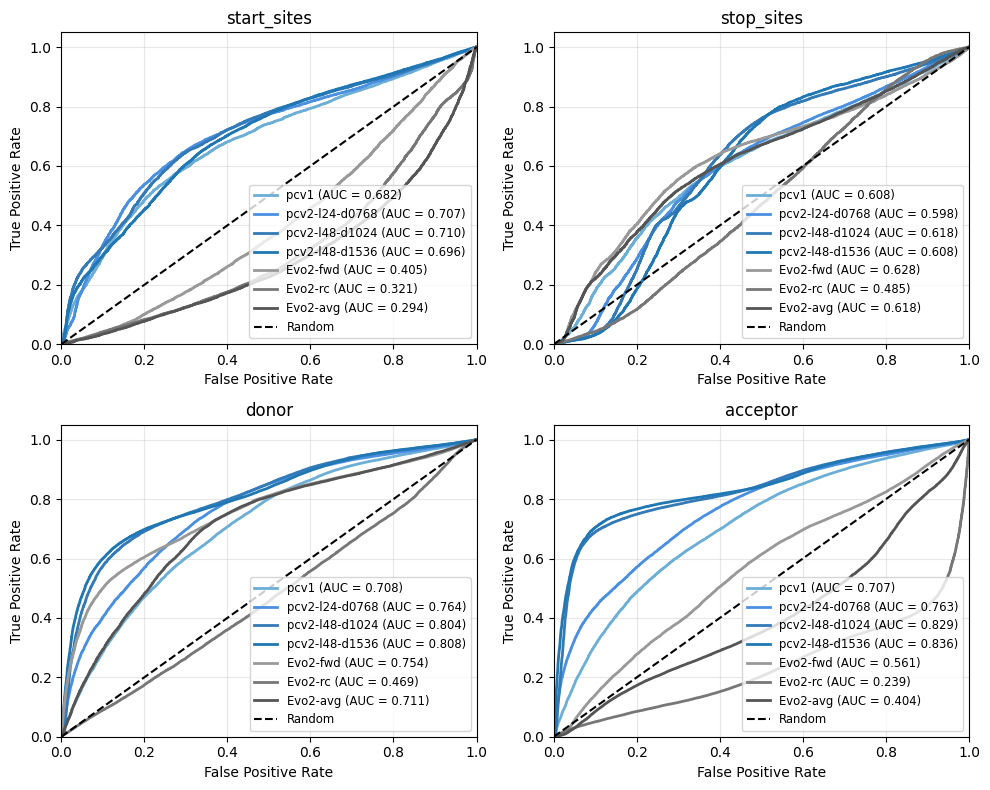

In [4]:
colors = ['#6baed6', '#4a90e2', '#337ab7', '#1f77b4', '#999999', '#777777', '#555555']

model_preds = [
    ('pcv1_scores', 'pcv1'),
    ('pcv2_1_scores', 'pcv2-l24-d0768'),
    ('pcv2_2_scores', 'pcv2-l48-d1024'),
    ('pcv2_3_scores', 'pcv2-l48-d1536'),
    ('evo2_fwd_scores', 'Evo2-fwd'),
    ('evo2_rc_scores', 'Evo2-rc'),
    ('evo2_avg_scores', 'Evo2-avg')
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes_flat = axes.flatten()

for idx, (dataset_name, df) in enumerate(labels_dict.items()):
    ax = axes_flat[idx]
    
    subsets = df[df['Label'] != 'Near-Core Gene'].copy()
    subsets['binary_label'] = subsets['Label'].apply(create_binary_labels)
    y_true = subsets['binary_label'].values

    # Plot ROC for each model
    for model_idx, (pred_col, label) in enumerate(model_preds):
        y_scores = subsets[pred_col].values
        fpr, tpr, _ = roc_curve(y_true, y_scores)
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f'{label} (AUC = {roc_auc:.3f})',
                color=colors[model_idx], linewidth=2)
    
    ax.plot([0, 1], [0, 1], 'k--', label='Random')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{dataset_name}')
    ax.legend(loc='lower right', fontsize='small')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])

plt.tight_layout()
plt.savefig('Core_noncore_classification.pdf', format='pdf', bbox_inches='tight')
plt.show()